## What changed vs `Pipeline_Alignment_MUSTANG.ipynb`

- **Alignment logic**: replaced full-PDB MUSTANG alignment with **flank-only alignment** to reduce bias:
  - Segment N: **DFG-40 → DFG** (includes DFG motif)
  - Segment C: **APE → APE+40** (includes APE motif)
  - **Exclude** the activation-loop residues between DFG and APE.
- **Transform transfer**: compute a rigid transform \((R,t)\) from the flank alignment and apply it to the **full original PDB** (all atoms).
- **Compatibility**: a dedicated section rebuilds the original pipeline artifacts (same filenames/schema) expected by downstream notebooks.


In [1]:
import numpy as np
import os
import glob 
import time 
import pandas as pd
import shutil
import re
import mdtraj as md
import MDAnalysis as mda
import pickle
import pickle as p 
import csv
import sys
import subprocess
import xml.etree.ElementTree as ET
import requests
import concurrent.futures
import multiprocessing
import nglview as nv
import h5py
import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches
import html
import biobox as bb
import tempfile
import matplotlib.pyplot as plt
import molearn
import torch
import glob as glob
import MDAnalysis.analysis.rms as rms
import seaborn as sns
import pickle
import networkx as nx
sys.path.insert(0, os.path.join(os.path.abspath(os.pardir),'src'))

from Bio import PDB
from tqdm import tqdm
from time import time as t
from urllib.request import urlretrieve as download
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.Blast.Applications import NcbipsiblastCommandline
from collections import defaultdict
from Bio.PDB import PPBuilder
from Bio.SeqUtils import seq1
from modeller import *
from modeller.automodel import *
from Bio.PDB import PDBParser
from MDAnalysis.analysis import align
from mpi4py import MPI
from glob import glob
from pprint import pprint as pp
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from glob import glob as g
from tqdm.notebook import tqdm
from collections import Counter
from matplotlib.ticker import FuncFormatter
from collections import defaultdict
from pymol import cmd
from scipy.interpolate import interp1d
from mpl_toolkits import mplot3d
from scipy import stats
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from matplotlib.colors import BoundaryNorm
from numpy.linalg import norm
from molearn.data import PDBData
from molearn.trainers import Trainer
from molearn.models.small_foldingnet import Small_AutoEncoder
from molearn.analysis.analyser import MolearnAnalysis
from copy import deepcopy
from molearn.analysis import MolearnGUI
from scipy.ndimage import rotate
from numpy.linalg import inv
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score
from itertools import combinations
from urllib.request import urlretrieve
from urllib.error import URLError
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.tree import export_graphviz
from sklearn import tree
from scipy.stats import pearsonr


/data/student/yuxiz/envs/project/lib/python3.10/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/data/student/yuxiz/envs/project/lib/python3.10/site-packages/molearn/trainers/sinkhorn_trainer.py:13: UserWarning: No module named 'geomloss'. Will not be able to use sinkhorn because geomloss is not installed.
  warnings.warn(f'{e}. Will not be able to use sinkhorn because geomloss is not installed.')


/data/student/yuxiz/envs/project/lib/python3.10/site-packages/molearn/scoring/__init__.py:26: UserWarning: No module named 'iotbx'. Will not be able to calculate Ramachandran score.
  warnings.warn(f"{e}. Will not be able to calculate Ramachandran score.")


In [2]:
def create_nonreconstructed_folder():
    unaligned_dir = "Results/activation_segments/unaligned"
    reconstructed_dir = "Results/activation_segments/reconstructedModeller"
    target_dir = "Results/activation_segments/nonReconstructed4Mustang"
    
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"Created directory: {target_dir}")
    
    unaligned_files = [f for f in os.listdir(unaligned_dir) if f.endswith('.pdb')]
    reconstructed_files = [f for f in os.listdir(reconstructed_dir) if f.endswith('.pdb')]
    
    # Extract the first 6 characters of each reconstructed filename to identify corresponding entries
    reconstructed_prefixes = {f[:6] for f in reconstructed_files}
    
    copied_count = 0
    skipped_count = 0
    
    for unaligned_file in unaligned_files:
        file_prefix = unaligned_file[:6]
        
        if file_prefix in reconstructed_prefixes:
            source_path = os.path.join(unaligned_dir, unaligned_file)
            target_path = os.path.join(target_dir, unaligned_file)
            
            # Copy unaligned file to the target directory if it was reconstructed
            shutil.copy(source_path, target_path)
            copied_count += 1
        else:
            skipped_count += 1
    
    print(f"Copied {copied_count} files from '{unaligned_dir}' to '{target_dir}'")
    print(f"Skipped {skipped_count} files that don't have matching entries in '{reconstructed_dir}'")
    print(f"These files have matching entries in '{reconstructed_dir}' based on the first 6 characters")

if __name__ == '__main__':
    create_nonreconstructed_folder()
    print("Processing complete!")

Copied 3847 files from 'Results/activation_segments/unaligned' to 'Results/activation_segments/nonReconstructed4Mustang'
Skipped 8468 files that don't have matching entries in 'Results/activation_segments/reconstructedModeller'
These files have matching entries in 'Results/activation_segments/reconstructedModeller' based on the first 6 characters
Processing complete!


In [3]:
"""
Filter PDB files from a directory that contain the specific structural motifs DFG and APE, ensuring that they appear in a valid order (with DFG preceding APE and a reasonable distance between them). Qualified structures are copied to a new directory for further use, and all processing details are recorded in a log file for review and traceability.
"""
import os
import shutil
from glob import glob
from Bio.PDB import PDBParser, PPBuilder

pdb_dir = "Results/activation_segments/nonReconstructed4Mustang/"
filtered_dir = "Results/activation_segments/nonReconstructed4Mustang_filtered/"
log_dir = "Results/activation_segments/nonReconstructed4Mustang_filtered/"
log_file = os.path.join(log_dir, "motif_verification_log.txt")

os.makedirs(filtered_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

print(f"Created/verified directories:\n- {filtered_dir}\n- {log_dir}")

with open(log_file, 'w') as f:
    f.write("Motif Verification Log\n")
    f.write("=====================\n\n")

def log_message(message):
    """Write message to log file and print to console."""
    print(message)
    try:
        with open(log_file, 'a') as f:
            f.write(message + "\n")
    except Exception as e:
        print(f"WARNING: Could not write to log file: {e}")

def extract_atom_sequence(pdb_file):
    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure('PDB', pdb_file)
        
        for model in structure:
            for chain in model:
                ppb = PPBuilder()
                sequence = ''
                for pp in ppb.build_peptides(chain):
                    sequence += pp.get_sequence()
                return str(sequence)
    except Exception as e:
        log_message(f"Error extracting sequence from {pdb_file}: {e}")
    return None

def find_motif_indices(seq, motif):
    index = seq.find(motif)
    if index == -1:
        return None
    return index, index + len(motif)

def find_dfg_motif_index(seq):
    for motif in ["DFG"]:
        result = find_motif_indices(seq, motif)
        if result is not None:
            return result, motif
    return None, None

def find_ape_motif_index(seq):
    for motif in ["APE"]:
        result = find_motif_indices(seq, motif)
        if result is not None:
            return result, motif
    return None, None

def filter_structures_by_motifs():
    # Check if input directory exists
    if not os.path.exists(pdb_dir):
        log_message(f"ERROR: Input directory does not exist: {pdb_dir}")
        return False
        
    fps = glob(pdb_dir + "/*.pdb")
    log_message(f"Found {len(fps)} PDB files to check.")
    
    valid_count = 0
    invalid_count = 0
    
    for fp in fps:
        pdb_code = os.path.basename(fp).split('.')[0]
        log_message(f"\nChecking {pdb_code}...")
        
        seq = extract_atom_sequence(fp)
        if seq is None:
            log_message(f"  - Could not extract sequence. Skipping.")
            invalid_count += 1
            continue
        
        dfg_result, dfg_motif = find_dfg_motif_index(seq)
        
        ape_result, ape_motif = find_ape_motif_index(seq)

        # Only keep files where both DFG and APE motifs are found
        if dfg_result is not None and ape_result is not None:
            dfg_start, dfg_end = dfg_result
            ape_start, ape_end = ape_result
            
            # Motifs must appear in correct order and be at least 5 residues apart
            if dfg_start < ape_start and (ape_start - dfg_end) >= 5:
                log_message(f"  - Found {dfg_motif} at position {dfg_start} and {ape_motif} at position {ape_start}")
                
                # Copy the valid PDB file to the filtered directory
                dest_path = os.path.join(filtered_dir, os.path.basename(fp))
                shutil.copy(fp, dest_path)
                log_message(f"  - Copying to {dest_path}")
                valid_count += 1
            else:
                log_message(f"  - Found motifs but in wrong order or too close: {dfg_motif}({dfg_start}) and {ape_motif}({ape_start})")
                invalid_count += 1
        else:
            # Log which motif was missing
            if dfg_result is None:
                log_message(f"  - DFG motif not found")
            if ape_result is None:
                log_message(f"  - APE motif not found")
            invalid_count += 1
    
    # Summary of results
    log_message(f"\nFiltering complete:")
    log_message(f"  - {valid_count} structures have valid DFG and APE motifs")
    log_message(f"  - {invalid_count} structures were excluded")
    log_message(f"  - Valid structures copied to {filtered_dir}")
    
    return valid_count > 0

if __name__ == '__main__':
    log_message(f"Starting filtering process. Working directory: {os.getcwd()}")
    log_message(f"Using input directory: {pdb_dir}")
    log_message(f"Output directory: {filtered_dir}")
    
    log_message("Filtering structures based on presence of DFG and APE motifs...")
    motifs_present = filter_structures_by_motifs()
    
    if motifs_present:
        log_message("\nFiltering process complete! Filtered structures saved to:")
        log_message(filtered_dir)
    else:
        log_message("No valid structures found with both DFG and APE motifs.")

Created/verified directories:
- Results/activation_segments/nonReconstructed4Mustang_filtered/
- Results/activation_segments/nonReconstructed4Mustang_filtered/
Starting filtering process. Working directory: /data/student/yuxiz/Autoencoders-to-Construct-Latent-Space-BRAF
Using input directory: Results/activation_segments/nonReconstructed4Mustang/
Output directory: Results/activation_segments/nonReconstructed4Mustang_filtered/
Filtering structures based on presence of DFG and APE motifs...
Found 3847 PDB files to check.

Checking 4FZ6_A...
  - Found DFG at position 142 and APE at position 166
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/4FZ6_A.pdb

Checking 6VNL_B...
  - Found DFG at position 159 and APE at position 186
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/6VNL_B.pdb

Checking 8AHG_A...
  - Found DFG at position 159 and APE at position 183
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/8

  - Found DFG at position 173 and APE at position 194
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/3AGL_A.pdb

Checking 8V2F_C...


  - Found DFG at position 171 and APE at position 195
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/8V2F_C.pdb

Checking 5DA3_A...


  - Found DFG at position 144 and APE at position 169
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/5DA3_A.pdb

Checking 5N3R_A...


  - Found DFG at position 171 and APE at position 192
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/5N3R_A.pdb

Checking 3D83_A...
  - Found DFG at position 162 and APE at position 184
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/3D83_A.pdb

Checking 5LCT_A...
  - Found DFG at position 185 and APE at position 206
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/5LCT_A.pdb

Checking 4NU1_A...
  - Found DFG at position 172 and APE at position 196
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/4NU1_A.pdb

Checking 3TKI_A...


...

  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/1H25_C.pdb

Checking 8P5K_B...


  - Found DFG at position 157 and APE at position 180
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/8P5K_B.pdb

Checking 2G01_B...
  - Found DFG at position 160 and APE at position 184
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/2G01_B.pdb

Checking 7R9T_A...
  - Found DFG at position 152 and APE at position 177
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/7R9T_A.pdb

Checking 2F57_B...
  - Found DFG at position 167 and APE at position 191
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/2F57_B.pdb

Checking 8AO7_A...
  - Found DFG at position 155 and APE at position 183
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/8AO7_A.pdb

Checking 1Z9X_A...
  - Found DFG at position 159 and APE at position 183
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/1Z9X_A.pdb

Checking 1JLU_E...
  - Found DFG at position 17

  - Found DFG at position 159 and APE at position 183
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/2A27_E.pdb

Checking 7S46_A...
  - Found DFG at position 158 and APE at position 183
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/7S46_A.pdb

Checking 3MSS_C...
  - Found DFG at position 147 and APE at position 172
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/3MSS_C.pdb

Checking 4U44_B...
  - Found DFG at position 155 and APE at position 180
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/4U44_B.pdb

Checking 5WEV_A...
  - Found DFG at position 158 and APE at position 184
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/5WEV_A.pdb

Checking 2Y9Q_A...
  - Found DFG at position 158 and APE at position 186
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/2Y9Q_A.pdb

Checking 4FTL_A...
  - Found DFG at position 13

  - Found DFG at position 151 and APE at position 177
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/4OW8_A.pdb

Checking 3I7B_A...


  - Found DFG at position 149 and APE at position 173
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/3I7B_A.pdb

Checking 1G3N_A...
  - Found DFG at position 154 and APE at position 178
  - Copying to Results/activation_segments/nonReconstructed4Mustang_filtered/1G3N_A.pdb

Filtering complete:
  - 3808 structures have valid DFG and APE motifs
  - 39 structures were excluded
  - Valid structures copied to Results/activation_segments/nonReconstructed4Mustang_filtered/

Filtering process complete! Filtered structures saved to:
Results/activation_segments/nonReconstructed4Mustang_filtered/


In [4]:
"""
Batch MUSTANG alignment for DFG-40 → DFG and APE → APE+40 flanking segments.

- Template PDB: 6UAN_chainD.pdb
- Target PDBs:  Results/activation_segments/nonReconstructed4Mustang_filtered/*.pdb
- For each target:
    * Extract two flanking segments:
         Segment 1: DFG-40 → DFG
         Segment 2: APE → APE+40
    * Run MUSTANG on the combined segment PDBs
    * Save outputs under:
      Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/<PDB_NAME>/40DFGextended_alignment/
- Save global RMSD summary to:
      Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/mustang_rmsd_40DFGextended_summary.txt
"""

import os
import subprocess
from glob import glob
from time import time
from Bio.PDB import PDBParser, PPBuilder, PDBIO, Select

# ----------------- paths & globals -----------------
template_full_pdb = "6UAN_chainD.pdb"
pdb_path = "Results/activation_segments/nonReconstructed4Mustang_filtered"

target_root = "Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD"
os.makedirs(target_root, exist_ok=True)

mustang_exe = "mustang"
flank = 40  


# ----------------- helper: extract two flanking segments -----------------
def extract_flanking_segment(input_pdb, output_pdb, flank=50):
    """
    Extract two flanking segments:
        Segment 1: DFG-flank → DFG
        Segment 2: APE → APE+flank
    Excludes DFG...APE middle region entirely.
    """

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("struct", input_pdb)

    # 1. first model + first chain
    model = next(structure.get_models())
    chain = next(model.get_chains())

    ppb = PPBuilder()
    peptides = list(ppb.build_peptides(chain))
    if not peptides:
        raise RuntimeError(f"No polypeptide built from first chain in {input_pdb}")

    seq_chars = []
    residue_list = []

    # concatenate full sequence
    for pp in peptides:
        seq_str = str(pp.get_sequence())
        residues = list(pp)
        for aa, res in zip(seq_str, residues):
            seq_chars.append(aa)
            residue_list.append(res)

    seq = "".join(seq_chars)

    # 2. find DFG & APE
    dfg_idx = seq.find("DFG")
    ape_idx = seq.find("APE")

    if dfg_idx == -1 or ape_idx == -1 or ape_idx <= dfg_idx:
        raise ValueError(f"Cannot find ordered DFG..APE in {input_pdb}")

    # 3. compute segment boundaries
    seg1_start = max(0, dfg_idx - flank)
    seg1_end   = dfg_idx + 3

    seg2_start = ape_idx
    seg2_end   = min(len(seq), ape_idx + 3 + flank)

    seg_residues = set()

    # segment 1: DFG-40 → DFG
    for i in range(seg1_start, seg1_end):
        seg_residues.add(residue_list[i])

    # segment 2: APE → APE+40
    for i in range(seg2_start, seg2_end):
        seg_residues.add(residue_list[i])

    # 4. save PDB
    class SegmentSelect(Select):
        def accept_residue(self, residue):
            return residue in seg_residues

    io = PDBIO()
    io.set_structure(structure)
    io.save(output_pdb, SegmentSelect())

    print(
        f"[Segment] {os.path.basename(input_pdb)}: "
        f"DFG idx = {dfg_idx}, APE idx = {ape_idx}, "
        f"Seg1 [{seg1_start}:{seg1_end}], "
        f"Seg2 [{seg2_start}:{seg2_end}], "
        f"Total = {len(seg_residues)} residues "
        f"-> saved to {output_pdb}"
    )

    return output_pdb


# ----------------- main batch loop -----------------
def main():
    start_time = time()

    pdb_files = sorted(glob(os.path.join(pdb_path, "*.pdb")))
    if not pdb_files:
        print(f"No PDB files found in {pdb_path}")
        return

    summary_path = os.path.join(target_root, "mustang_rmsd_40DFGextended_summary.txt")
    with open(summary_path, "w") as summary_f:
        summary_f.write("PDB_Name\tRMSD\n")

        # global template
        template_ext_global = os.path.join(target_root, "6UAN_chainD_40DFGextended.pdb")
        if not os.path.exists(template_ext_global):
            extract_flanking_segment(template_full_pdb, template_ext_global, flank=flank)

        for pdb_file in pdb_files:
            pdb_name = os.path.splitext(os.path.basename(pdb_file))[0]

            struct_dir = os.path.join(target_root, pdb_name, "40DFGextended_alignment")
            os.makedirs(struct_dir, exist_ok=True)

            template_seg_pdb = template_ext_global
            target_seg_pdb = os.path.join(struct_dir, f"{pdb_name}_40DFGextended.pdb")

            try:
                extract_flanking_segment(pdb_file, target_seg_pdb, flank=flank)
            except Exception as e:
                print(f"Failed to extract segment for {pdb_name}: {e}")
                continue

            # MUSTANG output prefix
            output_prefix = os.path.join(struct_dir, f"{pdb_name}_40DFGextended")

            cmd = [
                mustang_exe,
                "-i", template_seg_pdb, target_seg_pdb,
                "-o", output_prefix,
                "-F", "fasta",
                "-s", "ON",
                "-r", "ON",
            ]

            print(f"Running MUSTANG: {' '.join(cmd)}")

            result = subprocess.run(cmd, capture_output=True, text=True)
            if result.returncode != 0:
                print(f"MUSTANG failed for {pdb_name}")
                continue

            # parse RMSD
            rms_file = output_prefix + ".rms_rot"
            rms_value = None

            if os.path.exists(rms_file):
                with open(rms_file, "r") as f:
                    for line in f:
                        if line.strip().startswith("2|"):
                            parts = line.strip().split("|")[-1].split()
                            for p in parts:
                                try:
                                    rms_value = float(p)
                                    break
                                except:
                                    pass
                            break

            if rms_value is None:
                print(f"Failed to parse RMSD for {pdb_name}")
                continue

            print(f"Successfully aligned {pdb_name}, RMSD = {rms_value:.3f}")

            summary_f.write(f"{pdb_name}\t{rms_value:.3f}\n")

    print(f"Processing complete in {time() - start_time:.3f} seconds")
    print(f"RMSD summary saved to {summary_path}")


if __name__ == "__main__":
    main()


[Segment] 1A9U_A.pdb: DFG idx = 164, APE idx = 186, Seg1 [124:167], Seg2 [186:229], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1A9U_A/40DFGextended_alignment/1A9U_A_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1A9U_A/40DFGextended_alignment/1A9U_A_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1A9U_A/40DFGextended_alignment/1A9U_A_40DFGextended -F fasta -s ON -r ON
Successfully aligned 1A9U_A, RMSD = 2.200
[Segment] 1AD5_A.pdb: DFG idx = 320, APE idx = 336, Seg1 [280:323], Seg2 [336:379], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1AD5_A/40DFGextended_alignment/1AD5_A_40DFGextended.pdb

Successfully aligned 1AD5_A, RMSD = 1.900
[Segment] 1AD5_B.pdb: DFG idx = 320, APE idx = 336, Seg1 [280:323], Seg2 [336:379], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1AD5_B/40DFGextended_alignment/1AD5_B_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1AD5_B/40DFGextended_alignment/1AD5_B_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1AD5_B/40DFGextended_alignment/1AD5_B_40DFGextended -F fasta -s ON -r ON


Successfully aligned 1AD5_B, RMSD = 1.900
[Segment] 1AGW_A.pdb: DFG idx = 156, APE idx = 183, Seg1 [116:159], Seg2 [183:226], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1AGW_A/40DFGextended_alignment/1AGW_A_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1AGW_A/40DFGextended_alignment/1AGW_A_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1AGW_A/40DFGextended_alignment/1AGW_A_40DFGextended -F fasta -s ON -r ON
Successfully aligned 1AGW_A, RMSD = 2.000


[Segment] 1APM_E.pdb: DFG idx = 173, APE idx = 194, Seg1 [133:176], Seg2 [194:237], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1APM_E/40DFGextended_alignment/1APM_E_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1APM_E/40DFGextended_alignment/1APM_E_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1APM_E/40DFGextended_alignment/1APM_E_40DFGextended -F fasta -s ON -r ON
Successfully aligned 1APM_E, RMSD = 2.000
[Segment] 1ATP_E.pdb: DFG idx = 169, APE idx = 190, Seg1 [129:172], Seg2 [190:233], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1ATP_E/40DFGextended_alignment/1ATP_E_40DFGextended.pdb

Successfully aligned 1ATP_E, RMSD = 1.700
[Segment] 1B38_A.pdb: DFG idx = 136, APE idx = 161, Seg1 [96:139], Seg2 [161:204], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1B38_A/40DFGextended_alignment/1B38_A_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1B38_A/40DFGextended_alignment/1B38_A_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/1B38_A/40DFGextended_alignment/1B38_A_40DFGextended -F fasta -s ON -r ON
Successfully aligned 1B38_A, RMSD = 2.300


...

[Segment] 8YGZ_A.pdb: DFG idx = 151, APE idx = 176, Seg1 [111:154], Seg2 [176:219], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/8YGZ_A/40DFGextended_alignment/8YGZ_A_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/8YGZ_A/40DFGextended_alignment/8YGZ_A_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/8YGZ_A/40DFGextended_alignment/8YGZ_A_40DFGextended -F fasta -s ON -r ON
Successfully aligned 8YGZ_A, RMSD = 5.100
[Segment] 8YHK_A.pdb: DFG idx = 160, APE idx = 185, Seg1 [120:163], Seg2 [185:228], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/8YHK_A/40DFGextended_alignment/8YHK_A_40DFGextended.pdb

[Segment] 9BYJ_A.pdb: DFG idx = 322, APE idx = 348, Seg1 [282:325], Seg2 [348:391], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9BYJ_A/40DFGextended_alignment/9BYJ_A_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9BYJ_A/40DFGextended_alignment/9BYJ_A_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9BYJ_A/40DFGextended_alignment/9BYJ_A_40DFGextended -F fasta -s ON -r ON
Successfully aligned 9BYJ_A, RMSD = 1.900
[Segment] 9CJ2_A.pdb: DFG idx = 163, APE idx = 182, Seg1 [123:166], Seg2 [182:225], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9CJ2_A/40DFGextended_alignment/9CJ2_A_40DFGextended.pdb

Successfully aligned 9CJ2_B, RMSD = 2.000
[Segment] 9D8S_A.pdb: DFG idx = 147, APE idx = 171, Seg1 [107:150], Seg2 [171:214], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9D8S_A/40DFGextended_alignment/9D8S_A_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9D8S_A/40DFGextended_alignment/9D8S_A_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9D8S_A/40DFGextended_alignment/9D8S_A_40DFGextended -F fasta -s ON -r ON
Successfully aligned 9D8S_A, RMSD = 1.900
[Segment] 9DW4_K.pdb: DFG idx = 172, APE idx = 194, Seg1 [132:175], Seg2 [194:237], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9DW4_K/40DFGe

[Segment] 9DW5_G.pdb: DFG idx = 172, APE idx = 193, Seg1 [132:175], Seg2 [193:236], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9DW5_G/40DFGextended_alignment/9DW5_G_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9DW5_G/40DFGextended_alignment/9DW5_G_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9DW5_G/40DFGextended_alignment/9DW5_G_40DFGextended -F fasta -s ON -r ON
Successfully aligned 9DW5_G, RMSD = 1.800
[Segment] 9DW7_G.pdb: DFG idx = 172, APE idx = 194, Seg1 [132:175], Seg2 [194:237], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9DW7_G/40DFGextended_alignment/9DW7_G_40DFGextended.pdb

[Segment] 9DW8_G.pdb: DFG idx = 164, APE idx = 185, Seg1 [124:167], Seg2 [185:228], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9DW8_G/40DFGextended_alignment/9DW8_G_40DFGextended.pdb
Running MUSTANG: mustang -i Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/6UAN_chainD_40DFGextended.pdb Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9DW8_G/40DFGextended_alignment/9DW8_G_40DFGextended.pdb -o Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9DW8_G/40DFGextended_alignment/9DW8_G_40DFGextended -F fasta -s ON -r ON
Successfully aligned 9DW8_G, RMSD = 2.000
[Segment] 9DW9_G.pdb: DFG idx = 172, APE idx = 193, Seg1 [132:175], Seg2 [193:236], Total = 86 residues -> saved to Results/activation_segments/nonReconstructed_filtered_mustang_40DFGextended_withRMSD/9DW9_G/40DFGextended_alignment/9DW9_G_40DFGextended.pdb

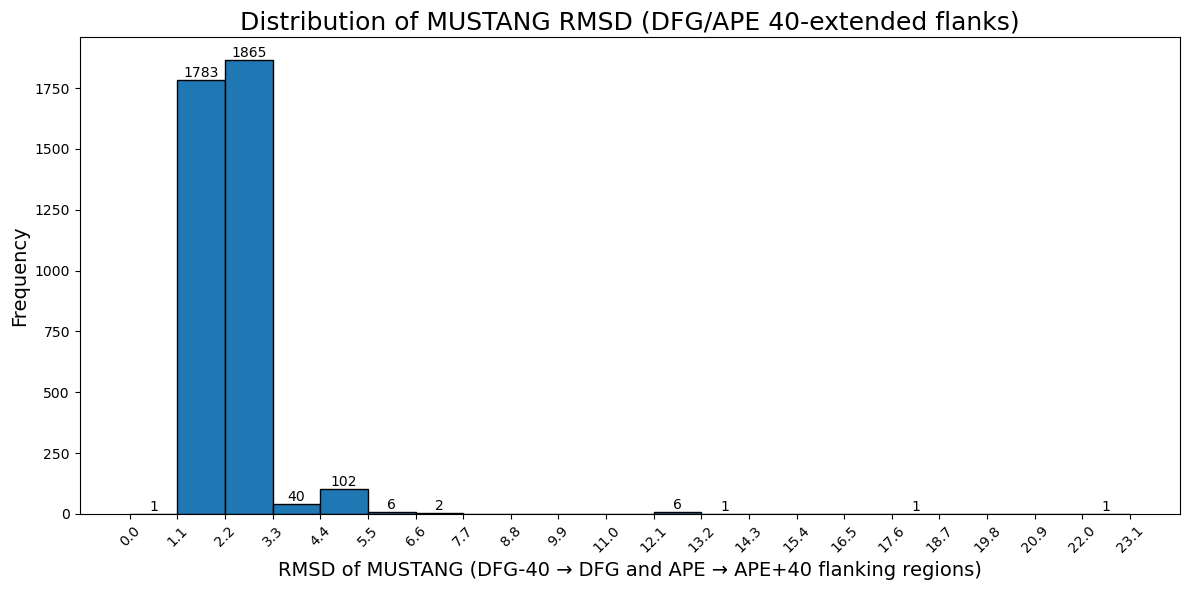

(0.0, 1.1]: 0 structures
(1.1, 2.2]: 2386 structures
  - 1A9U_A
  - 1AD5_A
  - 1AD5_B
  - 1AGW_A
  - 1APM_E
  - 1ATP_E
  - 1BKX_A
  - 1BL6_A
  - 1BL7_A
  - 1BMK_A
  - 1BX6_A
  - 1CDK_A
  - 1CDK_B
  - 1CMK_E
  - 1CTP_E
  - 1DI9_A
  - 1F5Q_A
  - 1FGI_A
  - 1FGK_A
  - 1FIN_A
  - 1FMO_E
  - 1FOT_A
  - 1FPU_A
  - 1FPU_B
  - 1FVV_C
  - 1GAG_A
  - 1GJO_A
  - 1GNG_B
  - 1HCK_A
  - 1IEP_A
  - 1IEP_B
  - 1IG1_A
  - 1IR3_A
  - 1IRK_A
  - 1J3H_A
  - 1J3H_B
  - 1JBP_E
  - 1JKK_A
  - 1JKL_A
  - 1JKS_A
  - 1JKT_A
  - 1JKT_B
  - 1JLU_E
  - 1JOW_B
  - 1KOA_A
  - 1KOB_A
  - 1KOB_B
  - 1KSW_A
  - 1L3R_E
  - 1M52_A
  - 1M52_B
  - 1M7Q_A
  - 1O6K_A
  - 1O6L_A
  - 1OEC_A
  - 1OI9_C
  - 1OKV_A
  - 1OKW_A
  - 1OL1_A
  - 1OPJ_A
  - 1OPJ_B
  - 1OPK_A
  - 1OPL_A
  - 1OPL_B
  - 1OUK_A
  - 1OUY_A
  - 1OVE_A
  - 1OZ1_A
  - 1P4F_A
  - 1PHK_A
  - 1PKG_A
  - 1PME_A
  - 1PXN_A
  - 1Q24_A
  - 1Q61_A
  - 1Q62_A
  - 1Q8T_A
  - 1Q8U_A
  - 1Q8W_A
  - 1QCF_A
  - 1QL6_A
  - 1QPC_A
  - 1QPD_A
  - 1QPE_A
  - 1QPJ_A
  - 1R39_A
 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====== 1. Load updated RMSD summary file ======
input_file = (
    "Results/activation_segments/"
    "nonReconstructed_filtered_mustang_40DFGextended_withRMSD/"
    "mustang_rmsd_40DFGextended_summary.txt"
)

df = pd.read_csv(input_file, sep=r"\s+", engine="python")

# ====== 2. Save a sorted version ======
df_sorted = df.sort_values(by="RMSD", ascending=False)
df_sorted.to_csv("sorted_rmsd_mustang_40DFGextended_summary.txt",
                 sep="\t", index=False)

# ====== 3. Histogram bin setting ======
bin_width = 1.1
bins = np.arange(0, df["RMSD"].max() + bin_width, bin_width)

plt.figure(figsize=(12, 6))

# ====== 4. Plot histogram ======
n, bins_plot, patches = plt.hist(
    df["RMSD"],
    bins=bins,
    edgecolor='black'
)

# Annotate counts
for count, x in zip(n, bins_plot[:-1]):
    if count > 0:
        plt.text(
            x + bin_width / 2,
            count,
            str(int(count)),
            ha='center',
            va='bottom',
            fontsize=10
        )

# ====== 5. Labels & title ======
plt.xlabel("RMSD of MUSTANG (DFG-40 → DFG and APE → APE+40 flanking regions)",
           fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Distribution of MUSTANG RMSD (DFG/APE 40-extended flanks)",
          fontsize=18)

plt.xticks(bins_plot, rotation=45, fontsize=10)
plt.tight_layout()

plt.savefig("ends_rmsd_mustang_40DFGextended.png", dpi=300)
plt.show()

# ====== 6. Group by bins ======
df["RMSD_bin"] = pd.cut(df["RMSD"], bins=bins)
grouped = df.groupby("RMSD_bin")["PDB_Name"].apply(list)

# Print grouped result
for interval, pdb_list in grouped.items():
    print(f"{interval}: {len(pdb_list)} structures")
    for pdb in pdb_list:
        print(f"  - {pdb}")

# ====== 7. Save grouped results ======
output_txt = "rmsd_bins_with_pdb_names_40DFGextended.txt"
with open(output_txt, "w") as f:
    for interval, pdb_list in grouped.items():
        f.write(f"{interval}: {len(pdb_list)} structures\n")
        for pdb in pdb_list:
            f.write(f"  - {pdb}\n")
        f.write("\n")


In [6]:
import shutil, subprocess, os
print("which mustang:", shutil.which("mustang"))


which mustang: /data/student/yuxiz/envs/project/bin/mustang


In [7]:
# --- MUSTANG flank alignment → full-PDB transform transfer (3-PDB stability test) ---
# Confirmed inputs/outputs:
#   targets_dir: Results/activation_segments/nonReconstructed4Mustang_filtered/
#   out_full_aligned_dir: Results/activation_segments/Mustang_with_singlechain_withoutlier/
# Test only:
#   5FWM_K.pdb, 1FOT_A.pdb, 6DC0_A.pdb

import os
import pickle
import csv

import mustang_full_align as mfa

# Confirmed paths (do NOT guess)
targets_dir = "Results/activation_segments/nonReconstructed4Mustang_filtered/"
out_full_aligned_dir = "Results/activation_segments/Mustang_with_singlechain_withoutlier/"

# Template
template_full_pdb = "6UAN_chainD.pdb"

# User-confirmed MUSTANG binary
mustang_exe = "/data/student/yuxiz/envs/project/bin/mustang"

# Test set
test_pdb_files = ["5FWM_K.pdb", "1FOT_A.pdb", "6DC0_A.pdb"]

# Outputs
transforms_pkl = os.path.join(out_full_aligned_dir, "transforms.pkl")
transforms_csv = os.path.join(out_full_aligned_dir, "transforms.csv")
failures_csv = os.path.join(out_full_aligned_dir, "transforms_failures.csv")

os.makedirs(out_full_aligned_dir, exist_ok=True)

transforms = {}
failures = []

for fname in test_pdb_files:
    input_full_pdb = os.path.join(targets_dir, fname)
    name = os.path.splitext(os.path.basename(fname))[0]
    work_dir = os.path.join(out_full_aligned_dir, "_work", name)

    try:
        res = mfa.align_full_pdb_via_flanks(
            template_full_pdb=template_full_pdb,
            target_full_pdb=input_full_pdb,
            work_dir=work_dir,
            flank=40,
            mustang_exe=mustang_exe,
            mustang_target_chain_id="B",
        )

        # Save full aligned PDB in out_full_aligned_dir with original filename
        output_full_aligned_pdb = os.path.join(out_full_aligned_dir, fname)
        mfa.apply_rigid_transform_to_pdb(
            input_pdb=input_full_pdb,
            output_pdb=output_full_aligned_pdb,
            R=res["R"],
            t=res["t"],
        )

        transforms[name] = {
            "name": name,
            "input_full_pdb": input_full_pdb,
            "output_full_aligned_pdb": output_full_aligned_pdb,
            "n_points": int(res["n_points"]),
            "segment_rmsd_after_transform": float(res["segment_rmsd_after_transform"]),
            "mustang_rmsd": res.get("mustang_rmsd"),
            "mustang_target_chain_id": res.get("mustang_target_chain_id"),
            "R": res["R"],
            "t": res["t"],
        }

        print(
            f"[OK] {name}: n_points={transforms[name]['n_points']}, "
            f"segment_rmsd_after_transform={transforms[name]['segment_rmsd_after_transform']:.3f}, "
            f"mustang_rmsd={transforms[name]['mustang_rmsd']}"
        )

    except Exception as e:
        failures.append({"name": name, "input_full_pdb": input_full_pdb, "reason": str(e)})
        print(f"[FAIL] {name}: {e}")

# Save transforms.pkl
with open(transforms_pkl, "wb") as f:
    pickle.dump({"transforms": transforms, "failures": failures}, f)
print(f"Saved: {transforms_pkl}")

# Save transforms.csv
with open(transforms_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow([
        "name", "input_full_pdb", "output_full_aligned_pdb",
        "n_points", "segment_rmsd_after_transform", "mustang_rmsd", "mustang_target_chain_id",
        "t_x", "t_y", "t_z",
        "R_00", "R_01", "R_02", "R_10", "R_11", "R_12", "R_20", "R_21", "R_22",
    ])
    for name, rec in transforms.items():
        R = rec["R"].reshape(3, 3)
        t = rec["t"].reshape(3)
        w.writerow([
            name,
            rec["input_full_pdb"],
            rec["output_full_aligned_pdb"],
            rec["n_points"],
            rec["segment_rmsd_after_transform"],
            rec.get("mustang_rmsd"),
            rec.get("mustang_target_chain_id"),
            float(t[0]), float(t[1]), float(t[2]),
            float(R[0, 0]), float(R[0, 1]), float(R[0, 2]),
            float(R[1, 0]), float(R[1, 1]), float(R[1, 2]),
            float(R[2, 0]), float(R[2, 1]), float(R[2, 2]),
        ])
print(f"Saved: {transforms_csv}")

# Save failures log
with open(failures_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["name", "input_full_pdb", "reason"])
    w.writeheader()
    w.writerows(failures)
print(f"Saved: {failures_csv}")

print(f"Done. success={len(transforms)} fail={len(failures)}")


[OK] 5FWM_K: n_points=86, segment_rmsd_after_transform=0.000, mustang_rmsd=2.5


[OK] 1FOT_A: n_points=86, segment_rmsd_after_transform=0.000, mustang_rmsd=1.9
[OK] 6DC0_A: n_points=67, segment_rmsd_after_transform=0.000, mustang_rmsd=22.3
Saved: Results/activation_segments/Mustang_with_singlechain_withoutlier/transforms.pkl
Saved: Results/activation_segments/Mustang_with_singlechain_withoutlier/transforms.csv
Saved: Results/activation_segments/Mustang_with_singlechain_withoutlier/transforms_failures.csv
Done. success=3 fail=0


In [8]:
# --- Preflight check (mustang availability) ---
import os
import subprocess

mustang_exe = "/data/student/yuxiz/envs/project/bin/mustang"
print("mustang_exe:", mustang_exe)
print("exists:", os.path.exists(mustang_exe))

# MUSTANG v3.2.4 uses --help ("-h" prints an error but still proves the binary runs)
for args in (["-h"], ["--help"]):
    res = subprocess.run([mustang_exe, *args], capture_output=True, text=True)
    print("\ncmd:", " ".join([mustang_exe, *args]))
    print("exit:", res.returncode)
    print("stdout (first 400 chars):\n", (res.stdout or "")[:400])
    print("stderr (first 400 chars):\n", (res.stderr or "")[:400])


mustang_exe: /data/student/yuxiz/envs/project/bin/mustang
exists: True



cmd: /data/student/yuxiz/envs/project/bin/mustang -h
exit: 0
stdout (first 400 chars):
 
      MUSTANG (v3.2.4): A MUltiple STuructural AligNment alGorithm.        
 Authors:         A S Konagurthu,  J Whisstock, and P J Stuckey, A M Lesk. 
 Reference:       A S Konagurthu et al. Proteins 64(3):559-574, 2006       



stderr (first 400 chars):
 MUSTANG v3.2.4 Command Line error!
:: 1:: invalid option:   -h
Try 'mustang --help' for more information.


cmd: /data/student/yuxiz/envs/project/bin/mustang --help
exit: 0
stdout (first 400 chars):
 
      MUSTANG (v3.2.4): A MUltiple STuructural AligNment alGorithm.        
 Authors:         A S Konagurthu,  J Whisstock, and P J Stuckey, A M Lesk. 
 Reference:       A S Konagurthu et al. Proteins 64(3):559-574, 2006       



stderr (first 400 chars):
 MUSTANG Options: 
    -p  <path>
        Path to the directory holding the (PDB) structures to be aligned.
    -i  <struct-1> <struct-2> ...
        Input structures to be aligned. Note: if -p 

In [9]:
# --- Batch flank alignment → full-PDB transform transfer (FULL DATASET) ---
# Confirmed settings (do NOT guess)
import os
import collections
import statistics
import numpy as np

import mustang_full_align as mfa

mustang_exe = "/data/student/yuxiz/envs/project/bin/mustang"
targets_dir = "Results/activation_segments/nonReconstructed4Mustang_filtered/"
out_full_aligned_dir = "Results/activation_segments/Mustang_with_singlechain_withoutlier/"
template_full_pdb = "6UAN_chainD.pdb"

transforms_pkl = os.path.join(out_full_aligned_dir, "transforms.pkl")
transforms_csv = os.path.join(out_full_aligned_dir, "transforms.csv")

# Run batch (ALL PDBs)
summary = mfa.batch_align_full_pdbs_via_flanks(
    template_full_pdb=template_full_pdb,
    targets_dir=targets_dir,
    out_full_aligned_dir=out_full_aligned_dir,
    transforms_pkl=transforms_pkl,
    transforms_csv=transforms_csv,
    flank=40,
    mustang_exe=mustang_exe,
    mustang_target_chain_id="B",
    glob_pattern="*.pdb",
)
print("Batch summary:", summary)

# ---- Post-run reporting (as requested) ----
import pickle
with open(transforms_pkl, "rb") as f:
    payload = pickle.load(f)

transforms = payload.get("transforms", {})
failures = payload.get("failures", [])

# totals
all_targets = len([p for p in os.listdir(targets_dir) if p.endswith('.pdb')])
print("total targets:", all_targets)
print("success count:", len(transforms))
print("failure count:", len(failures))

# top 5 failure reasons
if failures:
    reason_counts = collections.Counter([str(x.get("reason", "")) for x in failures])
    print("top 5 failure reasons:")
    for reason, cnt in reason_counts.most_common(5):
        print(f"- ({cnt}) {reason[:200]}")
else:
    print("top 5 failure reasons: none")

# stats of MUSTANG RMSD + matched CA points
rmsds = []
pts = []
rows = []
for name, rec in transforms.items():
    r = rec.get("mustang_rmsd")
    n = rec.get("n_points")
    if r is not None:
        try:
            rmsds.append(float(r))
        except Exception:
            pass
    if n is not None:
        pts.append(int(n))
    rows.append((name, rec.get("mustang_rmsd"), rec.get("n_points")))

if rmsds:
    print("MUSTANG rmsd stats (min/median/mean/max):",
          float(np.min(rmsds)), float(np.median(rmsds)), float(np.mean(rmsds)), float(np.max(rmsds)))
else:
    print("MUSTANG rmsd stats: no rmsd values")

if pts:
    print("matched CA points stats (min/median/mean/max):",
          int(np.min(pts)), float(np.median(pts)), float(np.mean(pts)), int(np.max(pts)))
else:
    print("matched CA points stats: no point counts")

# worst 20 by MUSTANG RMSD
worst = []
for name, rec in transforms.items():
    r = rec.get("mustang_rmsd")
    n = rec.get("n_points")
    try:
        rf = float(r)
    except Exception:
        continue
    worst.append((rf, name, n))

worst.sort(reverse=True)
print("top 20 worst MUSTANG rmsd (name, rmsd, matched_points):")
for rf, name, n in worst[:20]:
    print(f"- {name}: rmsd={rf:.3f}, n_points={n}")


Batch summary: {'n_targets': 3808, 'n_success': 3808, 'n_fail': 0, 'out_full_aligned_dir': 'Results/activation_segments/Mustang_with_singlechain_withoutlier/', 'transforms_pkl': 'Results/activation_segments/Mustang_with_singlechain_withoutlier/transforms.pkl', 'transforms_csv': 'Results/activation_segments/Mustang_with_singlechain_withoutlier/transforms.csv'}
total targets: 3808
success count: 3808
failure count: 0
top 5 failure reasons: none
MUSTANG rmsd stats (min/median/mean/max): 0.0 2.2 2.3298319327731094 22.3
matched CA points stats (min/median/mean/max): 67 86.0 85.99185924369748 86
top 20 worst MUSTANG rmsd (name, rmsd, matched_points):
- 6DC0_A: rmsd=22.300, n_points=67
- 6DC0_B: rmsd=17.700, n_points=77
- 3HAV_C: rmsd=13.900, n_points=83
- 4DCA_A: rmsd=13.200, n_points=86
- 3UZR_A: rmsd=13.200, n_points=86
- 3HAM_B: rmsd=12.800, n_points=86
- 3HAV_B: rmsd=12.700, n_points=86
- 3HAV_A: rmsd=12.700, n_points=86
- 3HAM_A: rmsd=12.700, n_points=86
- 2JFL_A: rmsd=7.100, n_points=8

In [10]:
# --- Compatibility Output (drop-in replacement outputs) ---
# Reads intermediate full aligned PDBs from:
#   Results/activation_segments/Mustang_with_singlechain_withoutlier/
# Writes final compatibility outputs to:
#   Results/activation_segments/Mustang_with_singlechain/
# Also writes copies to repo root (so downstream notebooks run unchanged today).

import os
import re
import shutil
import pickle
import csv
from types import SimpleNamespace
from collections import Counter

import numpy as np
from Bio.PDB import PDBParser, PDBIO, Select, PPBuilder
from Bio import pairwise2  # NOTE: deprecated; ok for now, can switch to Bio.Align.PairwiseAligner later

# Confirmed locations
intermediate_dir = "Results/activation_segments/Mustang_with_singlechain_withoutlier/"
final_dir = "Results/activation_segments/Mustang_with_singlechain/"

mustang_exe = "/data/student/yuxiz/envs/project/bin/mustang"  # documented here for completeness

# Original outlier rule (from Pipeline_Alignment_MUSTANG.ipynb)
# - Select structures by MUSTANG RMSD cutoff
RMSD_CUTOFF = 11.0

os.makedirs(final_dir, exist_ok=True)

# ---- 1) Read intermediate transforms and choose inliers ----
inter_transforms_csv = os.path.join(intermediate_dir, "transforms.csv")
inter_failures_csv = os.path.join(intermediate_dir, "transforms_failures.csv")
inter_transforms_pkl = os.path.join(intermediate_dir, "transforms.pkl")

if not os.path.exists(inter_transforms_csv):
    raise FileNotFoundError(f"Missing {inter_transforms_csv} — run the batch flank alignment first.")

rows = []
with open(inter_transforms_csv, "r", newline="") as f:
    rdr = csv.DictReader(f)
    for r in rdr:
        rows.append(r)

# Inliers by RMSD cutoff
inlier_rows = []
outlier_rows = []
for r in rows:
    try:
        rmsd_val = float(r["mustang_rmsd"]) if r.get("mustang_rmsd") not in (None, "") else None
    except Exception:
        rmsd_val = None

    if rmsd_val is not None and rmsd_val <= RMSD_CUTOFF:
        inlier_rows.append(r)
    else:
        outlier_rows.append(r)

print(f"Intermediate aligned full PDBs (transforms.csv rows): {len(rows)}")
print(f"Inliers (MUSTANG RMSD <= {RMSD_CUTOFF}): {len(inlier_rows)}")
print(f"Outliers (MUSTANG RMSD >  {RMSD_CUTOFF} or missing): {len(outlier_rows)}")

# ---- 2) Extract the correct chain from each full aligned PDB into final_dir ----
parser = PDBParser(QUIET=True)

class ChainSelect(Select):
    def __init__(self, keep_chain_id: str):
        self.keep_chain_id = keep_chain_id

    def accept_chain(self, chain):
        return chain.id == self.keep_chain_id


def chain_id_from_filename(fname: str) -> str:
    """Infer chain ID from filenames like 5FWM_K.pdb -> 'K'."""
    stem = os.path.splitext(os.path.basename(fname))[0]
    if "_" not in stem:
        raise ValueError(f"Cannot infer chain id from filename without '_': {fname}")
    return stem.rsplit("_", 1)[-1]

copied = 0
skipped = []

for r in inlier_rows:
    name = r["name"]
    input_full_aligned = os.path.join(intermediate_dir, f"{name}.pdb")
    if not os.path.exists(input_full_aligned):
        skipped.append((name, "missing_intermediate_full_aligned_pdb"))
        continue

    try:
        keep_chain = chain_id_from_filename(f"{name}.pdb")
    except Exception as e:
        skipped.append((name, f"chain_id_parse_error: {e}"))
        continue

    out_single_chain = os.path.join(final_dir, f"{name}.pdb")

    try:
        struct = parser.get_structure("s", input_full_aligned)
        io = PDBIO()
        io.set_structure(struct)
        io.save(out_single_chain, select=ChainSelect(keep_chain))
        copied += 1
    except Exception as e:
        skipped.append((name, f"chain_extract_error: {e}"))

print(f"Wrote single-chain PDBs to {final_dir}: {copied}")
if skipped:
    print(f"Skipped during chain extraction: {len(skipped)} (showing up to 10)")
    for item in skipped[:10]:
        print("-", item)

# ---- 3) Write final transforms logs (filtered to inliers) into final_dir ----
final_transforms_csv = os.path.join(final_dir, "transforms.csv")
final_transforms_pkl = os.path.join(final_dir, "transforms.pkl")
final_failures_csv = os.path.join(final_dir, "transforms_failures.csv")

# failures = (intermediate failures) + (chain-extraction skips)
failures_out = []
# carry over intermediate failures (if any)
if os.path.exists(inter_failures_csv):
    with open(inter_failures_csv, "r", newline="") as f:
        rdr = csv.DictReader(f)
        for fr in rdr:
            failures_out.append(fr)
# add chain extraction skips
for name, reason in skipped:
    failures_out.append({"name": name, "input_full_pdb": os.path.join(intermediate_dir, f"{name}.pdb"), "reason": reason})

# write transforms.csv
fieldnames = [
    "name","input_full_pdb","output_full_aligned_pdb",
    "n_points","segment_rmsd_after_transform","mustang_rmsd","mustang_target_chain_id",
    "t_x","t_y","t_z",
    "R_00","R_01","R_02","R_10","R_11","R_12","R_20","R_21","R_22",
]
with open(final_transforms_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    for r in inlier_rows:
        # update output path to final single-chain PDB
        r2 = dict(r)
        r2["output_full_aligned_pdb"] = os.path.join(final_dir, f"{r['name']}.pdb")
        w.writerow({k: r2.get(k, "") for k in fieldnames})

with open(final_failures_csv, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["name","input_full_pdb","reason"])
    w.writeheader()
    w.writerows(failures_out)

# write transforms.pkl (simple dict)
with open(final_transforms_pkl, "wb") as f:
    pickle.dump({"transforms_rows": inlier_rows, "failures": failures_out, "rmsd_cutoff": RMSD_CUTOFF}, f)

print(f"Saved final transforms: {final_transforms_csv}")
print(f"Saved final transforms: {final_transforms_pkl}")
print(f"Saved final failures:   {final_failures_csv}")

# ---- 4) Rebuild aligned_data.pkl/new_aligned_data.pkl/filtered_aligned_data.pkl ----
# We intentionally use SimpleNamespace objects so downstream notebooks can unpickle without custom class definitions.

def extract_seq(pdb_path: str) -> str:
    """Extract sequence from first model/first chain via PPBuilder."""
    s = parser.get_structure("x", pdb_path)
    model = next(s.get_models())
    chain = next(model.get_chains())
    ppb = PPBuilder()
    peptides = list(ppb.build_peptides(chain))
    if not peptides:
        return ""
    return "".join(str(pp.get_sequence()) for pp in peptides)

# template sequence
template_pdb = "6UAN_chainD.pdb"
template_seq = extract_seq(template_pdb)
if not template_seq:
    raise RuntimeError(f"Could not extract template sequence from {template_pdb}")

# scoring tuned to keep motifs aligned (heuristic, but robust)
ALIGN_MATCH = 2
ALIGN_MISMATCH = -1
ALIGN_GAP_OPEN = -10
ALIGN_GAP_EXTEND = -0.5

aligned = []
seq_fail = []

# Only build alignments for the inlier set (do not accidentally include extra PDBs
# that may already exist in final_dir from previous runs).
expected_pdb_files = [f"{r['name']}.pdb" for r in inlier_rows]
pdb_files = sorted([f for f in expected_pdb_files if os.path.exists(os.path.join(final_dir, f))])

for fname in pdb_files:
    name = os.path.splitext(fname)[0]
    fp = os.path.join(final_dir, fname)
    tgt_seq = extract_seq(fp)
    if not tgt_seq:
        seq_fail.append((name, "empty_target_sequence"))
        continue

    alns = pairwise2.align.globalms(template_seq, tgt_seq,
                                   ALIGN_MATCH, ALIGN_MISMATCH,
                                   ALIGN_GAP_OPEN, ALIGN_GAP_EXTEND,
                                   one_alignment_only=True)
    if not alns:
        seq_fail.append((name, "no_alignment_returned"))
        continue

    seq1_aln, seq2_aln, score, b, e = alns[0]
    aligned.append(SimpleNamespace(name=name, seq1=seq1_aln, seq2=seq2_aln))

print(f"Built aligned_data objects: {len(aligned)}")
if seq_fail:
    print(f"Sequence alignment failures: {len(seq_fail)} (showing up to 10)")
    for x in seq_fail[:10]:
        print("-", x)

# Save aligned_data.pkl (final dir)
aligned_data_path = os.path.join(final_dir, "aligned_data.pkl")
with open(aligned_data_path, "wb") as f:
    pickle.dump(aligned, f)

# ---- original filtering logic (ported from Pipeline_Alignment_MUSTANG.ipynb) ----
# Filter out structures where seq1 lacks DFG/APE
bad = []
new_aligned = []
for a in aligned:
    if a.seq1.find("DFG") == -1 or a.seq1.find("APE") == -1:
        bad.append(a)
    else:
        new_aligned.append(a)

new_aligned_data_path = os.path.join(final_dir, "new_aligned_data.pkl")
with open(new_aligned_data_path, "wb") as f:
    pickle.dump(new_aligned, f)

# Only keep structures where both DFG and APE are not aligned to gaps in seq2
counts = {}
counter = 0
new_aligned2 = []
aligning_segs = {}
lengths = []

for a in new_aligned:
    DFG_index = a.seq1.find("DFG")
    APE_index = a.seq1.find("APE")
    dfg = a.seq2[DFG_index]
    ape = a.seq2[APE_index]

    if dfg != "-" and ape != "-":
        counter += 1
        length = APE_index - DFG_index
        counts.setdefault(length, []).append((a.name, DFG_index, APE_index))
        new_aligned2.append(a)
        aligning_segs.setdefault(
            a.name,
            (a.seq2[DFG_index:DFG_index+3],
             a.seq2[APE_index:APE_index+3],
             a.seq2[DFG_index:APE_index+3])
        )
        lengths.append(len(a.seq2[DFG_index:APE_index+3]))

filtered_aligned_data_path = os.path.join(final_dir, "filtered_aligned_data.pkl")
with open(filtered_aligned_data_path, "wb") as f:
    pickle.dump({
        "new_aligned2": new_aligned2,
        "aligning_segs": aligning_segs,
        "counts": counts,
        "lengths": lengths,
    }, f)

# alignment_results.csv
alignment_results_csv = os.path.join(final_dir, "alignment_results.csv")
with open(alignment_results_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Name", "Seq1 Segment", "Seq2 Segment", "Status"])
    for a in new_aligned2:
        DFG_index = a.seq1.find("DFG")
        APE_index = a.seq1.find("APE")
        w.writerow([a.name, a.seq1[DFG_index:APE_index+3], a.seq2[DFG_index:APE_index+3], "Aligned"])
    for a in bad:
        w.writerow([a.name, "", "", "Not Aligned"])

print(f"Saved compatibility pickles in {final_dir}:")
print("-", aligned_data_path)
print("-", new_aligned_data_path)
print("-", filtered_aligned_data_path)
print("-", alignment_results_csv)

# ---- 5) Generate alignment_segment_with_index.csv and conservation_sorted.csv (downstream dependencies) ----

def template_residue_labels(template_pdb_path: str) -> list[str]:
    s = parser.get_structure("t", template_pdb_path)
    model = next(s.get_models())
    chain = next(model.get_chains())
    labels = []
    for res in chain:
        if "CA" in res:
            labels.append(f"{res.get_resname()}-{res.get_id()[1]}")
    return labels

x_lbl = template_residue_labels(template_pdb)

# alignment_segment_with_index.csv
seg_index_csv = os.path.join(final_dir, "alignment_segment_with_index.csv")

seq1mag = len(template_seq)  # template sequence length (ungapped)
counts_cov = np.zeros(seq1mag, dtype=float)
total_alignments = len(new_aligned2)

with open(seg_index_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["PDB_Name", "Template_Res", "Target_Res", "Template_Index", "Target_Index"])

    for a in new_aligned2:
        seq1 = a.seq1
        seq2 = a.seq2
        continuous_index = 0
        num_gap_seq2 = 0

        for idx, (res1, res2) in enumerate(zip(seq1, seq2), start=1):
            if res2 == "-":
                num_gap_seq2 += 1
            if res1 != "-":
                template_index = continuous_index
                target_index = idx - num_gap_seq2
                # label lookups (guard)
                template_res = x_lbl[template_index] if template_index < len(x_lbl) else "NA"
                w.writerow([a.name, res1, res2, template_index, target_index])
                if res2 != "-" and template_index < len(counts_cov):
                    counts_cov[template_index] += 1
                continuous_index += 1

# conservation_sorted.csv (same schema as original)
conservation = counts_cov / total_alignments if total_alignments else counts_cov

cons_rows = []
for i in range(len(conservation)):
    residue = x_lbl[i] if i < len(x_lbl) else "NA"
    cons_rows.append((i, residue, f"{conservation[i]*100:.2f}%"))

# sort by percentage desc
cons_rows_sorted = sorted(cons_rows, key=lambda x: float(x[2].rstrip('%')), reverse=True)

cons_sorted_csv = os.path.join(final_dir, "conservation_sorted.csv")
with open(cons_sorted_csv, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Template_Index", "Residue", "Conservation_Percentage"])
    for row in cons_rows_sorted:
        w.writerow(row)

print("Saved downstream-compat CSVs:")
print("-", seg_index_csv)
print("-", cons_sorted_csv)

# ---- 6) ALSO write copies to repo root so downstream notebooks run unchanged today ----
root_copies = [
    (aligned_data_path, "aligned_data.pkl"),
    (new_aligned_data_path, "new_aligned_data.pkl"),
    (filtered_aligned_data_path, "filtered_aligned_data.pkl"),
    (alignment_results_csv, "alignment_results.csv"),
    (seg_index_csv, "alignment_segment_with_index.csv"),
    (cons_sorted_csv, "conservation_sorted.csv"),
]

for src, dst in root_copies:
    shutil.copy2(src, dst)
print("Wrote root copies for downstream notebooks:")
for _, dst in root_copies:
    print("-", dst)


Intermediate aligned full PDBs (transforms.csv rows): 3808
Inliers (MUSTANG RMSD <= 11.0): 3799
Outliers (MUSTANG RMSD >  11.0 or missing): 9


Wrote single-chain PDBs to Results/activation_segments/Mustang_with_singlechain/: 3799
Saved final transforms: Results/activation_segments/Mustang_with_singlechain/transforms.csv
Saved final transforms: Results/activation_segments/Mustang_with_singlechain/transforms.pkl
Saved final failures:   Results/activation_segments/Mustang_with_singlechain/transforms_failures.csv


Built aligned_data objects: 3799
Saved compatibility pickles in Results/activation_segments/Mustang_with_singlechain/:
- Results/activation_segments/Mustang_with_singlechain/aligned_data.pkl
- Results/activation_segments/Mustang_with_singlechain/new_aligned_data.pkl
- Results/activation_segments/Mustang_with_singlechain/filtered_aligned_data.pkl
- Results/activation_segments/Mustang_with_singlechain/alignment_results.csv


Saved downstream-compat CSVs:
- Results/activation_segments/Mustang_with_singlechain/alignment_segment_with_index.csv
- Results/activation_segments/Mustang_with_singlechain/conservation_sorted.csv
Wrote root copies for downstream notebooks:
- aligned_data.pkl
- new_aligned_data.pkl
- filtered_aligned_data.pkl
- alignment_results.csv
- alignment_segment_with_index.csv
- conservation_sorted.csv


In [11]:
import os, glob, pandas as pd, pickle

final_dir = "Results/activation_segments/Mustang_with_singlechain"
required = [
    "aligned_data.pkl",
    "new_aligned_data.pkl",
    "filtered_aligned_data.pkl",
    "alignment_results.csv",
    "alignment_segment_with_index.csv",
    "conservation_sorted.csv",
]

print("=== Existence check ===")
for f in required:
    path = os.path.join(final_dir, f)
    print(f, "OK" if os.path.exists(path) else "MISSING")

pdbs = glob.glob(os.path.join(final_dir, "*.pdb"))
print("PDB count in final_dir:", len(pdbs))

print("\n=== Quick load check ===")
for f in ["alignment_results.csv", "alignment_segment_with_index.csv", "conservation_sorted.csv"]:
    path = os.path.join(final_dir, f)
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f, "rows:", len(df), "cols:", len(df.columns))

for f in ["aligned_data.pkl", "new_aligned_data.pkl", "filtered_aligned_data.pkl"]:
    path = os.path.join(final_dir, f)
    if os.path.exists(path):
        with open(path, "rb") as fh:
            obj = pickle.load(fh)
        try:
            n = len(obj)
        except Exception:
            n = "unknown"
        print(f, "loaded, len =", n, "type =", type(obj))


=== Existence check ===
aligned_data.pkl OK
new_aligned_data.pkl OK
filtered_aligned_data.pkl OK
alignment_results.csv OK
alignment_segment_with_index.csv OK
conservation_sorted.csv OK
PDB count in final_dir: 3799

=== Quick load check ===
alignment_results.csv rows: 3398 cols: 4


alignment_segment_with_index.csv rows: 964748 cols: 5
conservation_sorted.csv rows: 284 cols: 3
aligned_data.pkl loaded, len = 3799 type = <class 'list'>
new_aligned_data.pkl loaded, len = 3798 type = <class 'list'>


filtered_aligned_data.pkl loaded, len = 4 type = <class 'dict'>
